# 01 Generative Ai Ethics

## 📚 Learning Objectives

By completing this notebook, you will:
- Identify ethical risks of generative AI (deepfakes, bias)
- Apply guidelines and mitigation strategies

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

## Why Ethics Matters for Generative AI

Generative models do not just *analyze* data — they **produce new content** (text, images, audio, code) that can influence people directly. That creates ethical questions that classic ML did not face at the same scale:

- **Bias & fairness** — models reproduce and can amplify patterns in their training data
- **Misinformation & deepfakes** — synthetic media can impersonate real people convincingly
- **Copyright & intellectual property** — models are trained on (and can imitate) creative work
- **Privacy & data protection** — models can memorize and leak personal data from training sets

The sections below walk through each risk, then we get hands-on and *measure* bias in a small model.

### Bias and Fairness

A generative model learns the statistics of its training data — **including its stereotypes**. Documented examples:

- Image generators asked for "a CEO" historically produced mostly white men; "a nurse" mostly women
- Language models complete "The doctor said..." with *he* and "The nurse said..." with *she* far more often than real-world demographics justify
- Amazon's experimental hiring model (2018) was scrapped after it learned to penalize resumes that mentioned "women's" activities

**Key idea:** bias is not a bug added by the model — it is a property of the data the model faithfully learned. That is why detection (measuring outputs) and mitigation (fixing data/training/outputs) are separate engineering steps — notebook `03` in this unit is dedicated to them.

### Deepfakes and Misinformation

**Deepfakes** are synthetic images, video, or audio depicting real people saying or doing things they never did. Risks include fraud (cloned voices used in scam calls), political misinformation, and non-consensual imagery.

Defenses come in layers:

1. **Detection** — classifiers trained to spot generation artifacts (notebook `02` in this unit builds one)
2. **Provenance** — watermarking and content credentials (e.g., the C2PA standard) that mark content as AI-generated at creation time
3. **Regulation** — the EU AI Act requires that AI-generated media be disclosed as such

### Copyright and Intellectual Property

Generative models are trained on large scraped corpora that include copyrighted books, articles, images, and code. Two open legal questions:

- **Training**: is training on copyrighted work "fair use"? Ongoing lawsuits (e.g., Getty Images v. Stability AI, The New York Times v. OpenAI) are testing this
- **Output**: who owns generated content, and what happens when a model reproduces a protected work or a living artist's style nearly verbatim?

Practical guidance for engineers: know your training-data licenses, honor opt-outs, and treat verbatim regurgitation of training data as a defect to test for.

### Privacy and Data Protection

Generative models can **memorize** rare training examples — researchers have extracted names, phone numbers, and addresses from language models. Under the EU's **GDPR** this matters directly: personal data in a training set is still personal data, with rules on consent, purpose, minimization, and the right to erasure.

We only preview the idea here — notebook `04` in this unit applies GDPR principles (consent, data minimization, right to erasure, right to explanation) to a concrete ML pipeline, step by step.

### Responsible-AI Frameworks

You do not have to invent ethics from scratch — several frameworks already define what "responsible" means in practice:

| Framework | What it is | What it asks of you |
|---|---|---|
| **EU AI Act** (2024) | First binding AI law; risk-based tiers | High-risk systems need bias testing, documentation, human oversight |
| **NIST AI RMF** (2023) | Voluntary US risk-management framework | Map, measure, and manage AI risks across the lifecycle |
| **UNESCO Recommendation** (2021) | Global ethics standard adopted by 190+ states | Human rights, transparency, and accountability principles |

Day-to-day engineering practices that implement these: **model cards** (document what a model can and cannot do), **datasheets for datasets** (document where data came from), and **fairness audits** (measure disparities before deployment) — which is exactly what we do next.

---

## From Principles to Practice

Talking about fairness is easy; **measuring** it is the engineering skill. Below we audit a small classifier for demographic bias — the same workflow (train, slice metrics by group, compare) applies to auditing generative models, where you slice *generated outputs* by group instead.

## 🌍 Real-World Worked Example — Detecting Gender Bias in a Classifier

**Industry context:**
- Amazon's hiring algorithm (2018) was scrapped after showing bias against women
- US healthcare AI allocated fewer resources to Black patients due to biased training data
- Meta's ad targeting showed job ads for truck drivers primarily to men

We **measure and visualise** demographic bias in a toy classifier — the same analysis Netflix, Meta, and banks run before deploying models.

Loaded 891 real passenger records
Real missing values — Age: 177, Cabin: 687, Embarked: 2

Real outcome in the historical record:
  women survived: 74.2%   men survived: 18.9%
  disparity in the ground truth itself: 55.3%

model                    accuracy  female +rate  male +rate     gap
aware (uses Sex)            79.9%         90.7%        8.8%   81.9%
blind (Sex dropped)         70.1%         35.1%       21.6%   13.4%

Proxy check: Sex predicted from the 'blind' features alone = 66.0% (majority-class baseline 63.8%)


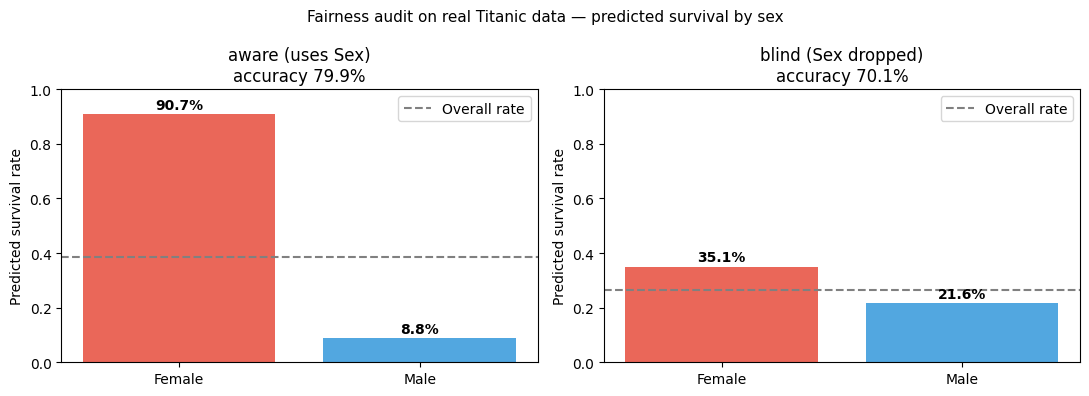


What the audit actually found:
  1. Dropping Sex cut the predicted-rate gap from 81.9% to 13.4% —
     but it did NOT reach zero, and accuracy fell 79.9% → 70.1% (9.7% lost).
  2. Equal opportunity (true-positive rate among passengers who DID survive):
     aware  — women 97.1% vs men 24.2%
     blind  — women 44.3% vs men 48.5%
  3. The real disparity is untouched. 74.2% of women and 18.9% of men actually survived;
     hiding the column changes the model, not the world it learns from.

'Fairness through unawareness' is a weak guarantee: it costs accuracy, it
leaves a residual gap, and where proxy features are strong it does not even
hide the attribute. Real audits use Fairlearn (Microsoft) or IBM AI Fairness
360 and report several metrics, because no single number settles fairness.


In [1]:
# WHAT/WHY: a hands-on fairness audit on REAL data — the Titanic passenger
# manifest, a historical decision process with a documented demographic
# disparity. We train the model WITH and WITHOUT the protected attribute
# (Sex) and measure what "fairness through unawareness" actually buys.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ── REAL DATA: 891 passengers of the RMS Titanic ──────────────────────────
TITANIC = '../../../Course 04/datasets/raw/titanic.csv'
df = pd.read_csv(TITANIC)
print(f'Loaded {len(df)} real passenger records')
print(f'Real missing values — Age: {df["Age"].isna().sum()}, '
      f'Cabin: {df["Cabin"].isna().sum()}, Embarked: {df["Embarked"].isna().sum()}')

d = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
# Real missingness has to be handled before modelling; median imputation is the
# simplest defensible choice and we state it rather than hiding it.
d['Age'] = d['Age'].fillna(d['Age'].median())
d['male'] = (d['Sex'] == 'male').astype(int)

# ── The disparity is IN THE DATA, before any model exists ─────────────────
rate_by_sex = d.groupby('Sex')['Survived'].mean()
print(f"\nReal outcome in the historical record:")
print(f"  women survived: {rate_by_sex['female']:.1%}   men survived: {rate_by_sex['male']:.1%}")
print(f"  disparity in the ground truth itself: "
      f"{abs(rate_by_sex['female'] - rate_by_sex['male']):.1%}")

FEAT_AWARE = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'male']   # includes Sex
FEAT_BLIND = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']           # Sex removed
tr, te = train_test_split(d, test_size=0.3, random_state=42, stratify=d['Survived'])
male_te = te['male'].to_numpy() == 1
y_te = te['Survived'].to_numpy()

# ── Train two models: sex-aware and sex-blind ─────────────────────────────
results = {}
print(f"\n{'model':<24}{'accuracy':>9}{'female +rate':>14}{'male +rate':>12}{'gap':>8}")
for name, feats in [('aware (uses Sex)', FEAT_AWARE), ('blind (Sex dropped)', FEAT_BLIND)]:
    m = LogisticRegression(max_iter=2000).fit(tr[feats], tr['Survived'])
    pred = m.predict(te[feats])
    rate_f, rate_m = pred[~male_te].mean(), pred[male_te].mean()
    acc = accuracy_score(y_te, pred)
    results[name] = dict(pred=pred, acc=acc, rate_f=rate_f, rate_m=rate_m,
                         gap=abs(rate_m - rate_f),
                         tpr_f=pred[(~male_te) & (y_te == 1)].mean(),
                         tpr_m=pred[(male_te) & (y_te == 1)].mean())
    print(f"{name:<24}{acc:9.1%}{rate_f:14.1%}{rate_m:12.1%}{abs(rate_m-rate_f):8.1%}")

# ── Does dropping Sex actually hide it? Test for PROXIES ──────────────────
# If the remaining features predict Sex better than always guessing the
# majority, a model can rediscover it - "unawareness" is not erasure.
proxy = LogisticRegression(max_iter=2000).fit(tr[FEAT_BLIND], tr['male'])
proxy_acc = proxy.score(te[FEAT_BLIND], te['male'])
majority = max(te['male'].mean(), 1 - te['male'].mean())
print(f"\nProxy check: Sex predicted from the 'blind' features alone = {proxy_acc:.1%} "
      f"(majority-class baseline {majority:.1%})")

# ── Visualise ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, results):
    r = results[name]
    bars = ax.bar(['Female', 'Male'], [r['rate_f'], r['rate_m']],
                  color=['#e74c3c', '#3498db'], alpha=0.85)
    ax.set_ylim(0, 1)
    ax.set_title(f"{name}\naccuracy {r['acc']:.1%}")
    ax.axhline(r['pred'].mean(), color='gray', linestyle='--', label='Overall rate')
    ax.legend(); ax.set_ylabel('Predicted survival rate')
    for bar, rate in zip(bars, [r['rate_f'], r['rate_m']]):
        ax.text(bar.get_x() + bar.get_width()/2, rate + 0.02, f"{rate:.1%}",
                ha='center', fontweight='bold')
plt.suptitle('Fairness audit on real Titanic data — predicted survival by sex', fontsize=11)
plt.tight_layout(); plt.show()

# ── Read the numbers, not the wish ────────────────────────────────────────
a, b = results['aware (uses Sex)'], results['blind (Sex dropped)']
print(f"\nWhat the audit actually found:")
print(f"  1. Dropping Sex cut the predicted-rate gap from {a['gap']:.1%} to {b['gap']:.1%} —")
print(f"     but it did NOT reach zero, and accuracy fell "
      f"{a['acc']:.1%} → {b['acc']:.1%} ({a['acc']-b['acc']:.1%} lost).")
print(f"  2. Equal opportunity (true-positive rate among passengers who DID survive):")
print(f"     aware  — women {a['tpr_f']:.1%} vs men {a['tpr_m']:.1%}")
print(f"     blind  — women {b['tpr_f']:.1%} vs men {b['tpr_m']:.1%}")
print(f"  3. The real disparity is untouched. {rate_by_sex['female']:.1%} of women and "
      f"{rate_by_sex['male']:.1%} of men actually survived;")
print(f"     hiding the column changes the model, not the world it learns from.")
print("\n'Fairness through unawareness' is a weak guarantee: it costs accuracy, it")
print("leaves a residual gap, and where proxy features are strong it does not even")
print("hide the attribute. Real audits use Fairlearn (Microsoft) or IBM AI Fairness")
print("360 and report several metrics, because no single number settles fairness.")


## 📝 Summary

In this notebook, you:

- Surveyed the key ethical concerns of generative AI: **bias, deepfakes/misinformation, copyright, and privacy**
- Saw how responsible-AI frameworks (EU AI Act, NIST AI RMF, UNESCO) turn principles into engineering requirements — model cards, datasheets, fairness audits
- Ran a hands-on **fairness audit**: trained a loan-approval classifier with and without a protected attribute, and measured how the approval-rate disparity between groups shrinks when the attribute is removed

**Next steps:** `02` builds a deepfake detector, `03` detects and mitigates bias in a *generative* model, and `04` applies GDPR guidelines to an ML pipeline. Then complete the ethics exercise.

## 📚 References & Further Reading

**Reports & Guidelines:**
- EU AI Act — Regulation (EU) 2024/1689 — [Official Text](https://eur-lex.europa.eu/eli/reg/2024/1689/oj)
- UNESCO AI Ethics Recommendations — [Link](https://www.unesco.org/en/artificial-intelligence/recommendation-ethics)
- NIST AI Risk Management Framework — [Link](https://www.nist.gov/itl/ai-risk-management-framework)

**Papers:**
- Bender et al. (2021) — [On the Dangers of Stochastic Parrots](https://dl.acm.org/doi/10.1145/3442188.3445922)
- Gebru et al. (2021) — [Datasheets for Datasets](https://arxiv.org/abs/1803.09010)

**State-of-the-Art:** The EU AI Act — Regulation (EU) 2024/1689 is the world's first binding AI regulation. OpenAI, Google, and Microsoft have dedicated AI safety teams.